## 🌧️ Seasonal and Monthly Microphysical Climatology

This analysis presents the monthly and seasonal variability of precipitation microphysics using \(D_m\), \(\log_{10}(N_w)\), and Liquid Water Content (LWC) distributions derived from disdrometer observations. 📊💧

The figures combine all available observations for each month (January–December) and for the main meteorological seasons:

- ❄️ **DJF** — December, January, February  
- 🌱 **MAM** — March, April, May  
- ☀️ **JJA** — June, July, August  
- 🍂 **SON** — September, October, November  

These climatological distributions allow the identification of seasonal changes in precipitation regimes, highlighting transitions between continental and maritime microphysical characteristics across the study region. 🌩️🌎

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import sys
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Import minor locator ticker
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from re import split
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import skew
import matplotlib.image as mpimg

from scipy import stats
from scipy.stats import norm, gamma, logistic, t, lognorm, expon, betaprime
# from scipy.special import gamma

from scipy.optimize import curve_fit

import calendar

# from dask_jobqueue import SLURMCluster

# from dask.distributed import Client, progress
from IPython.display import Image
from dask.distributed import Client
import folium

import warnings

warnings.filterwarnings('ignore')

import seaborn as sns
# import hvplot.xarray

import Functions as Func

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "resultados" / "Zarr"
FIG_PATH = PROJECT_ROOT / "figures"

instrument_path = FIG_PATH / "Montañita_San_Antonio"

instrument_path.mkdir(parents=True, exist_ok=True)


ds_JPC = xr.open_zarr(
    DATA_PATH / "425_filtrado_plot.zarr"
)

ds_JPC

<xarray.Dataset> Size: 19GB
Dimensions:       (time: 2574779, diameter: 22, velocity: 20)
Coordinates:
  * time          (time) datetime64[ns] 21MB 2020-02-13T16:22:00 ... 2025-04-...
  * diameter      (diameter) float64 176B 0.125 0.25 0.375 0.5 ... 7.0 7.5 8.0
  * velocity      (velocity) float64 160B 0.1 0.2 0.4 0.6 ... 7.4 8.2 9.0 10.0
Data variables: (12/19)
    Client        (time) <U1 10MB dask.array<chunksize=(10000,), meta=np.ndarray>
    MOR           (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    Synop_Code    (time) <U1 10MB dask.array<chunksize=(10000,), meta=np.ndarray>
    d_m_filt      (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    lwc_filt      (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    n_t           (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    ...            ...
    raw_filtrada  (time, diameter, velocity) float64 9GB dask.array<chunksize=(10000, 22, 20), meta=np.ndarray>
    ref           (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    ref_filt      (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    rl_int        (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    rs_int        (time) float64 21MB dask.array<chunksize=(10000,), meta=np.ndarray>
    vd            (diameter) float64 176B dask.array<chunksize=(22,), meta=np.ndarray>
Attributes:
    institution:  SIATA / Universidad del Quindío
    references:   {'[1]': 'https://doi.org/10.1175/JTECH-D-13-00174.1', '[2]'...
    title:        Thies Disdrometer Precipitation Dataset

In [3]:
start_date = pd.to_datetime(ds_JPC.time[0].values).strftime('%Y-%m-%d')
end_date = pd.to_datetime(ds_JPC.time[-1].values).strftime('%Y-%m-%d')

print(start_date, end_date)

2020-02-13 2025-04-10


In [26]:
# 🌧️ Select all months from all available years
ds_month = ds_JPC.where(ds_JPC.time.dt.month == 12, drop=True)

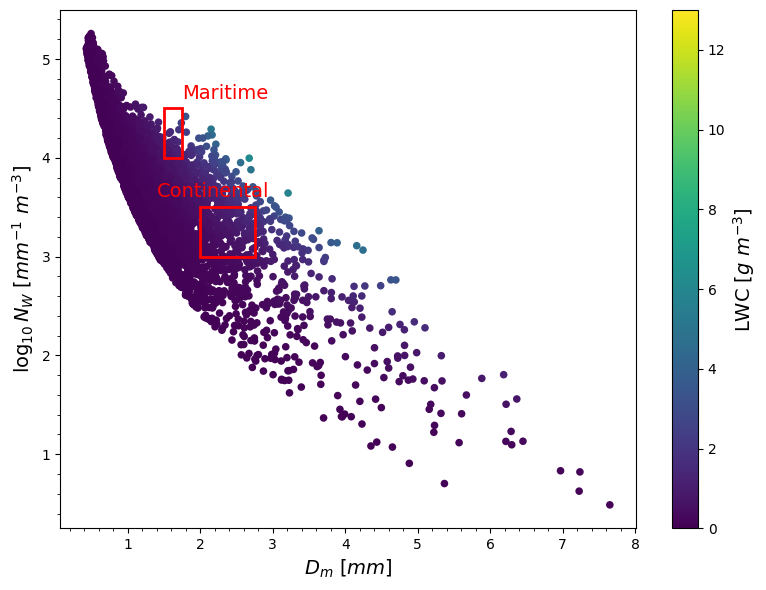

In [27]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
sc = ax.scatter(
    ds_month.d_m_filt,
    np.log10(ds_month.n_w_filt),
    c=ds_month.lwc_filt,
    cmap='viridis',
    norm=mcolors.Normalize(vmin=0, vmax=13),
    s=30,
    edgecolors='none'
)

# --- Maritime rectangle ---
rect1 = patches.Rectangle(
    (1.5, 4),
    width=0.25,
    height=0.5,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

# --- Continental rectangle ---
rect2 = patches.Rectangle(
    (2, 3),
    width=0.75,
    height=0.5,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

ax.add_patch(rect1)
ax.add_patch(rect2)

# Labels
ax.set_xlabel('$D_m\ [mm]$', fontsize=14)
ax.set_ylabel('$\log_{10}N_W\ [mm^{-1}\ m^{-3}]$', fontsize=14)

# Title
# ax.set_title(f'February Climatology ({start_date} to {end_date})', fontsize=16)
# ax.set_title(f'{start_date} to {end_date}', fontsize=16)

# Text labels
plt.text(1.4, 3.6, 'Continental', fontsize=14, color='red')
plt.text(1.75, 4.6, 'Maritime', fontsize=14, color='red')

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('LWC $[g\ m^{-3}]$', fontsize=14)

# Minor ticks
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig(instrument_path / "Montañita_San_Antonio_Decembers.png", 
            dpi=300, 
            bbox_inches='tight')
plt.show()

In [34]:
# 🌦️ Select season
ds_season = ds_JPC.where(
    ds_JPC.time.dt.month.isin([3, 4, 5]),
    drop=True
)

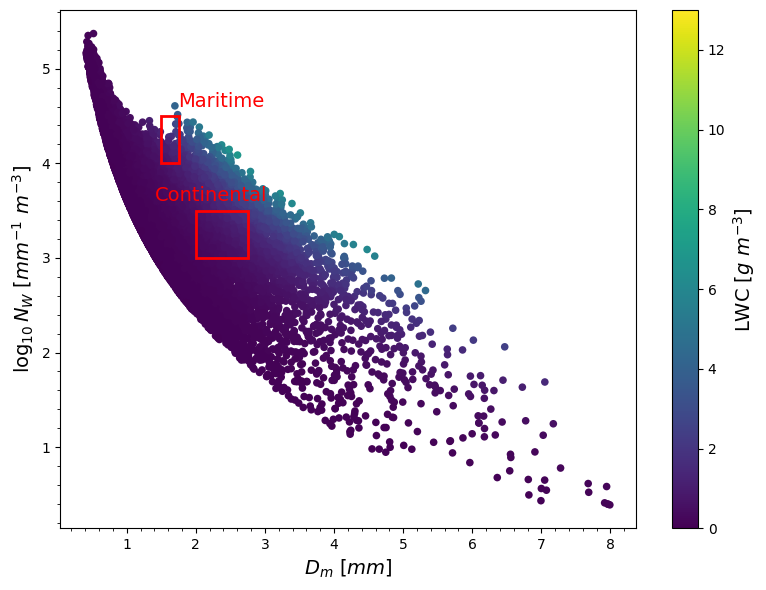

In [35]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
sc = ax.scatter(
    ds_season.d_m_filt,
    np.log10(ds_season.n_w_filt),
    c=ds_season.lwc_filt,
    cmap='viridis',
    norm=mcolors.Normalize(vmin=0, vmax=13),
    s=30,
    edgecolors='none'
)

# --- Maritime rectangle ---
rect1 = patches.Rectangle(
    (1.5, 4),
    width=0.25,
    height=0.5,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

# --- Continental rectangle ---
rect2 = patches.Rectangle(
    (2, 3),
    width=0.75,
    height=0.5,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

ax.add_patch(rect1)
ax.add_patch(rect2)

# Labels
ax.set_xlabel('$D_m\ [mm]$', fontsize=14)
ax.set_ylabel('$\log_{10}N_W\ [mm^{-1}\ m^{-3}]$', fontsize=14)

# Title
# ax.set_title(f'February Climatology ({start_date} to {end_date})', fontsize=16)
# ax.set_title(f'SON Climatology', fontsize=16)

# Text labels
plt.text(1.4, 3.6, 'Continental', fontsize=14, color='red')
plt.text(1.75, 4.6, 'Maritime', fontsize=14, color='red')

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('LWC $[g\ m^{-3}]$', fontsize=14)

# Minor ticks
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig(instrument_path / "Montañita_San_Antonio_MAMs.png", 
            dpi=300, 
            bbox_inches='tight')
plt.show()

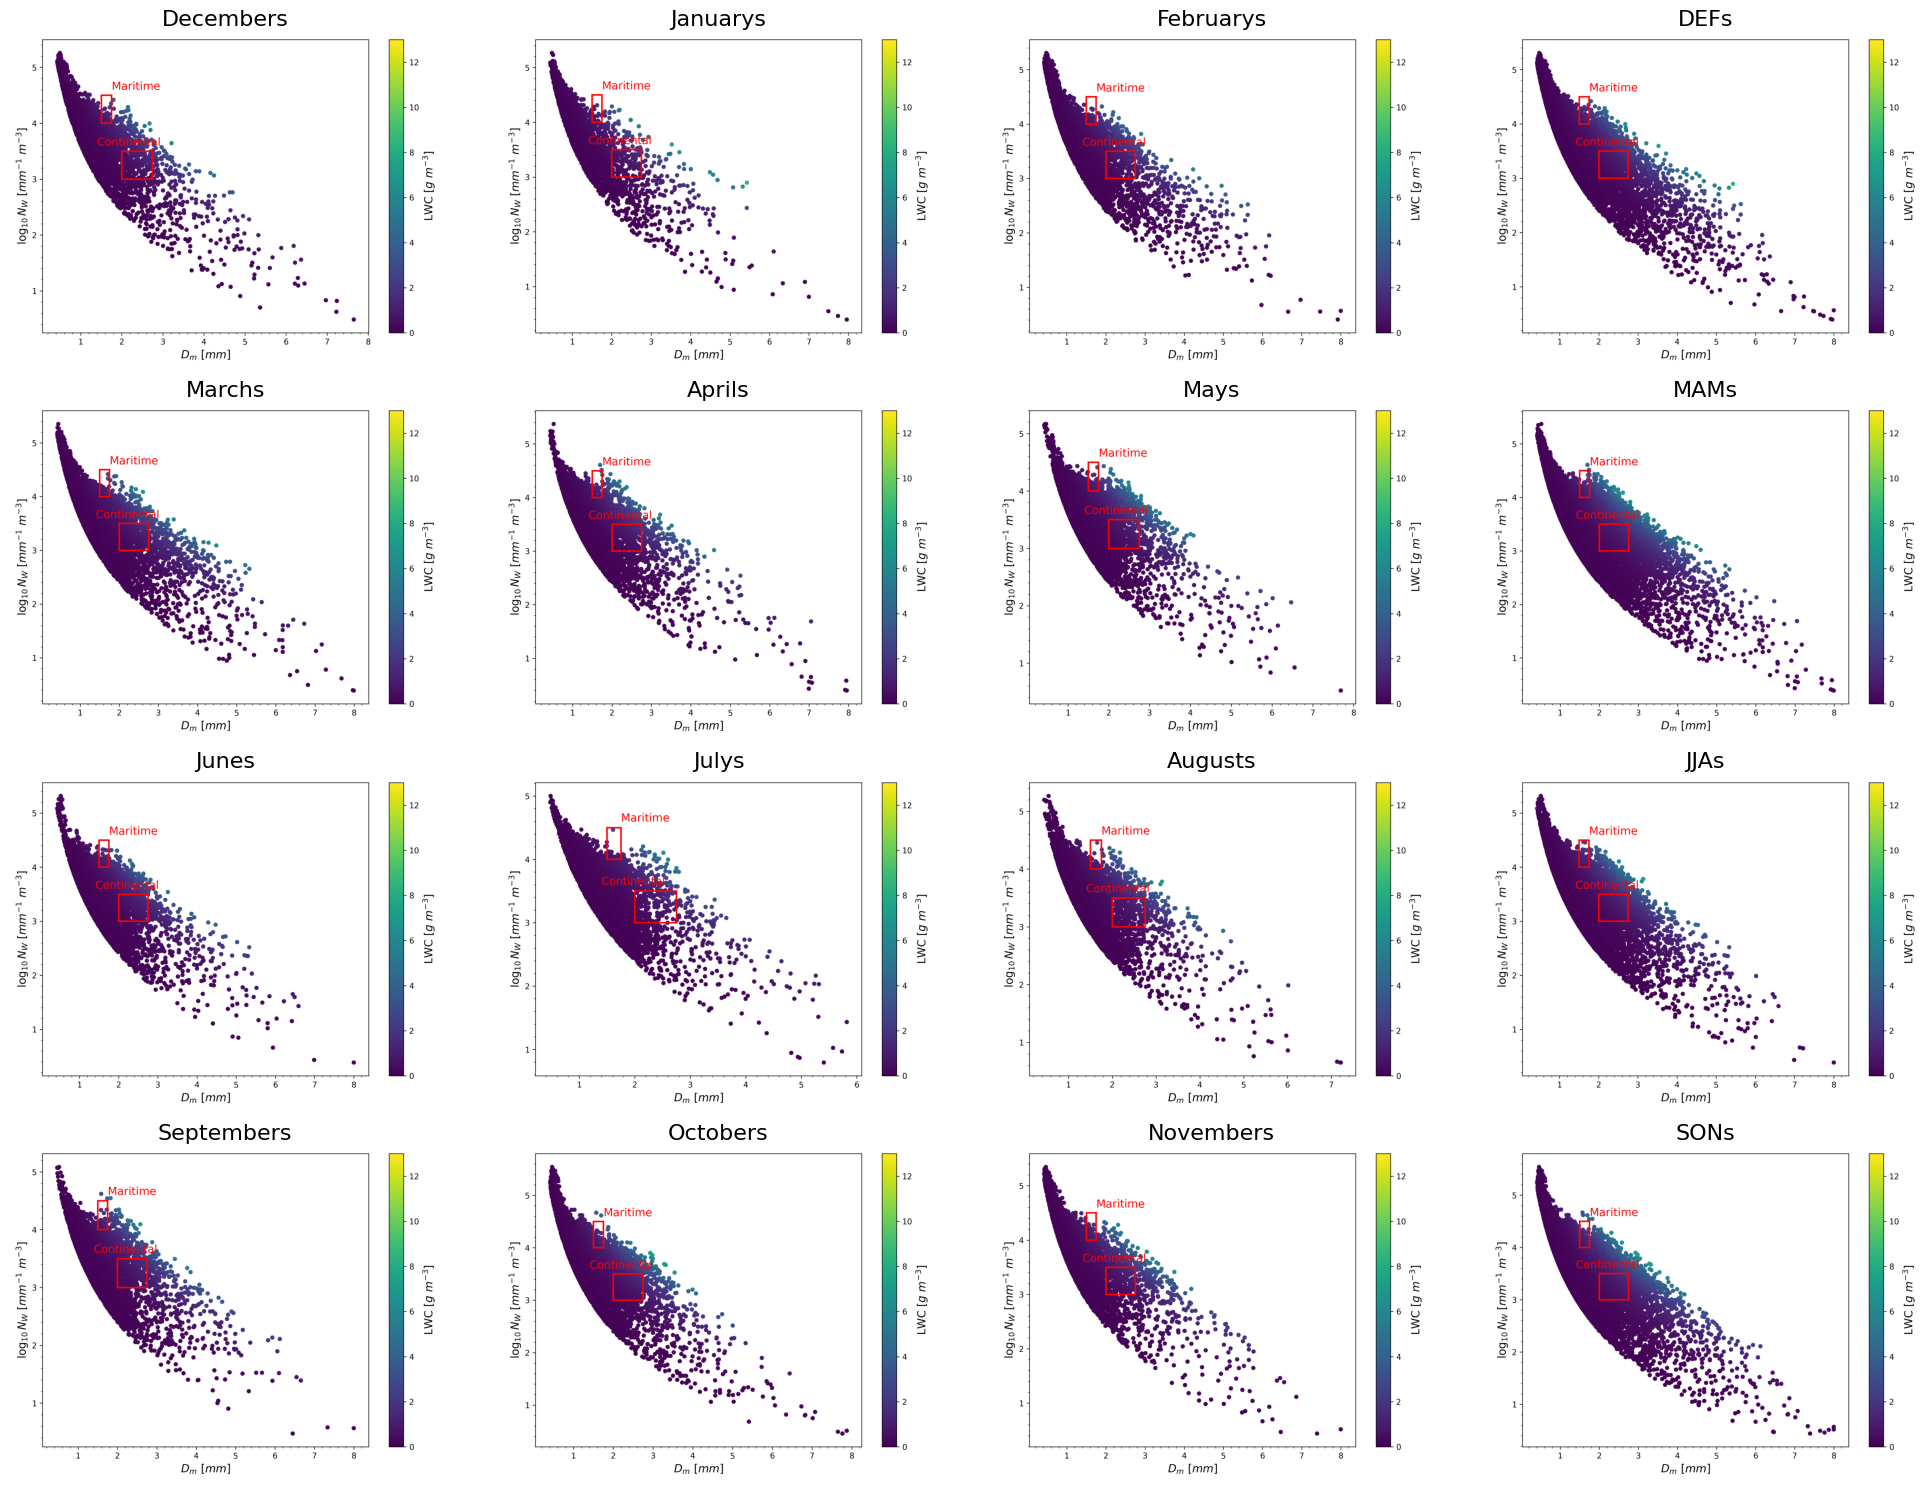

In [36]:
# 📅 Define the position of each month in the matrix
# (row, column)
month_positions = {
    "Januarys":   (0, 1),
    "Februarys":  (0, 2),
    "Marchs":     (1, 0),
    "Aprils":     (1, 1),

    "Mays":       (1, 2),
    "Junes":      (2, 0),
    "Julys":      (2, 1),
    "Augusts":    (2, 2),

    "Septembers": (3, 0),
    "Octobers":   (3, 1),
    "Novembers":  (3, 2),
    "Decembers":  (0, 0),

    "DEFs":      (0, 3),
    "MAMs":      (1, 3),
    "JJAs":      (2, 3),
    "SONs":      (3, 3)
}

# 🖼️ Create empty matrix figure
fig, axs = plt.subplots(4, 4, figsize=(20, 15))

# 🔁 Read all png files inside folder
files = glob.glob(os.path.join(instrument_path, "*.png"))

# 🔍 Loop through images
for file in files:

    filename = os.path.basename(file)

    # 📅 Identify month from filename
    for month, (row, col) in month_positions.items():

        # Example filename:
        # Santa_Rita_Guatape_Januarys.png
        if month in filename:

            # 📖 Read image
            img = mpimg.imread(file)

            # 📌 Plot image in corresponding position
            axs[row, col].imshow(img)

            # 🏷️ Optional title
            axs[row, col].set_title(month, fontsize=16)

            # ❌ Remove axes
            axs[row, col].axis('off')

# 🔧 Adjust spacing
plt.tight_layout()

# 💾 Save final matrix
plt.savefig(
    os.path.join(instrument_path, "Montañita_San_Antonio_Matrix.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()